# 1. 합성곱 신경망 (CNN)
- CNN: 이미지의 **공간 정보를 유지**한 상태로 학습이 가능한 방식

## 1-1. CNN을 사용하는 이유
- MLP는 픽셀을 일렬로 펼쳐 처리
- CNN은 이미지의 **2차원 구조를 유지**  
=> 이미지의 구조를 유지한 채 주변 픽셀 관계와 시각적 특징 학습이 가능한 CNN 활용  
<br>
- Convolution으로 특징(feature) 추출: 모델이 ‘특징’을 학습
- Pooling으로 차원 축소: 위치/크기 변화에 덜 민감하게 만듦  
=> 어떤 영역에 특정한 특징이 존재하는가를 보기 때문에 위치에 무관  
<br>
- 부분연결 구조 & Convolution 연산으로 이미지의 특정 피쳐에만 집중
- 효율적인 파라미터 사용  
=> MLP에서의 파라미터 급증 문제 완화  
<br>
- 다차원 이미지를 그대로 입력받고, 공간 정보를 보존하면서 학습
- 특징을 어느 정도 추출한 후 flatten -> 손실의 정도가 MLP보다 훨씬 낮음

## 1-2. 합성곱(Convolution)과 풀링(Pooling)
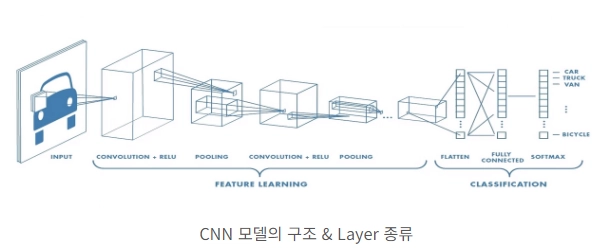  
- 특징 추출(Feature learning) 영역
    - Convolution Layer: 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소
    - Pooling Layer: Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 중요한 특징을 강조하는 역할
- 이미지 분류(Classification)를 하는 영역
    -  Fully Connected Layer
<br>
### 특징 추출(Feature learning) 영역
1. Convolution Layer: 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징 학습
    1. 필터(Filter) 또는 커널(Kernel)이 이미지 위를 슬라이딩
    2. 각 위치에서 요소별 곱셈 후 합계 계산
    3. 결과를 Feature Map에 저장
        - feature map: input data에 filter를 적용하여 얻은 결과물
        - feature map의 차원은 filter의 수에 따라 결정됨
<br>
2.  Padding: filter를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법  
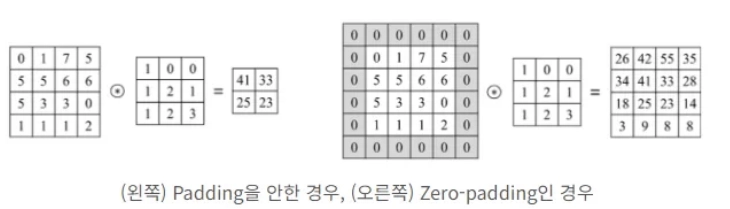
<br>
3. Stride (보폭): 이미지를 몇 칸씩 점프하면서 훑을 것인지 결정하는 값
    - stride가 커질 수록 feature map의 크기가 작아짐  
<br>
4. Pooling: 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것
    - **Max Pooling**: 최댓값 선택
    - Average Pooling: 평균값 선택


## 1-3. 대표적인 CNN 아키텍처
- AlexNet (2012): 머신러닝에서 벗어나 최초로 **GPU**를 이용해 학습한 대규모 CNN 모델
    - 5개의 Convolutional Layer + 3개의 Fully Connected Layers
    - 활성화 함수로 ReLU 함수를 이용해 **Vanishing gradient(기울기 소실)** 문제 해소  
- VGGNet (2014): 이미지 인식에 강한 깊은 층의 CNN 모델
    - Conv + Pool(max)을 **여러번** 반복
    - 이미 만들고 학습시킨 VGGNet 모델을 가져와 사용하는 전이 학습에 많이 쓰는 모델  
- ResNet (2015): **잔차 연결** 개념을 도입해 **깊은 신경망의 소실 문제**를 해결한 모델
    - 잔차 연결: 이전 레이어의 출력을 몇 레이어를 건너뛰고 다음 레이어의 입력으로 직접 추가하는 방식

# 2. 이미지 딥러닝 응용

## 2-1. 이미지 분류 (Image Classification)
- 이미지를 픽셀로 인식하여 사전 정의된 클래스 중 하나로 분류  

| 모델명 | 특징 요약 | 주의사항 |
|--------|----------|----------|
| AlexNet | 비교적 단순한 구조, 초기 CNN 모델들 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| VGG | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
| ResNet | Residual 연결 (skip connections) → 매우 깊은 네트워크 가능 | 과적합 주의, batch size / regularization 조절 필요 |
| Vision Transformer (ViT) | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |


## 2-2. 객체 탐지 (Object Detection)
- 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 **bounding box**를 찾는 작업  
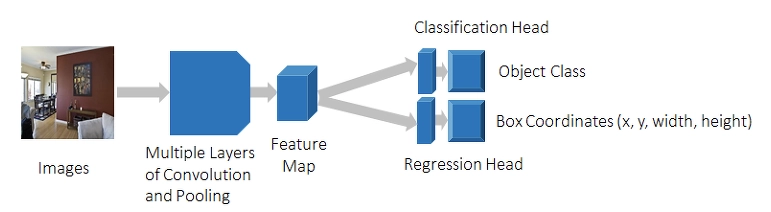  
- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올림
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측

## 2-3. 이미지 캡셔닝 (Image Captioning)
- 이미지 내에 있는 객체에 대한 판단뿐만 아니라 **객체들 간의 관계를 파악**하고 자연어의 형태로 알맞게 표현
- CNN을 이용한 특징 추출 -> Attention Network를 이용하여 단어 생성 -> RNN을 이용하여 문장 완성

# 3. 과거를 기억하는 신경망: RNN (Recurrent Neural Network)

## 3-1. 순차(Sequence) 데이터
- 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터
    - 순차 데이터, 시간적 순차 데이터, 시계열 데이터 
    - 음성 및 오디오, 자연어, 생물학적 서열, 비디오 데이터
- 순차 데이터의 특징:
    - **요소의 순서 의존성**: 데이터를 구성하는 요소들의 순서 자체가 핵심 정보
    - **자기상관성**: 이전 시점의 데이터가 다음 시점의 데이터에 영향을 미침

## 3-2. RNN의 구조와 원리
- RNN: 순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망
    - 시퀀스 데이터를 입력받아 순서 정보를 유지하며 처리
    - 순환하는 은닉층이 매 시점의 은닉 상태를 업데이트
        - 은닉층 (Hidden Layer): 신경망을 구성하는 물리적 요소
        - 은닉 상태 (Hidden State): 특정 시점(𝑡)에 은닉층을 통과한 결과값
    - 이전 시점의 값을 현재 시점으로 넘겨줌
<br>
- RNN 구조  
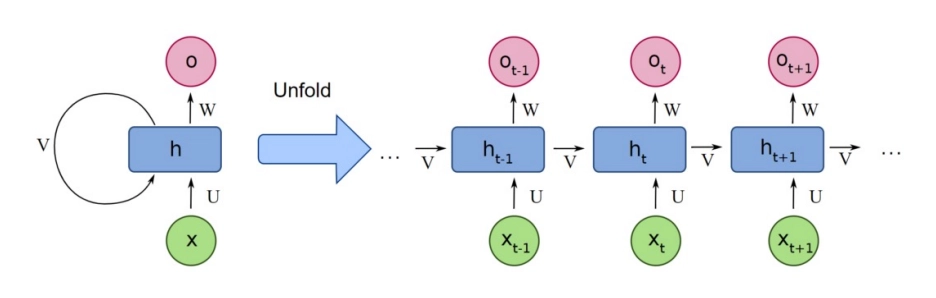  
    - **\( t-1 \) 시점**
        - 입력: \( x_{t-1} \)
        - 은닉 상태 업데이트: \( h_{t-1} \)
        - 출력: \( o_{t-1} \)
    -  **\( t \) 시점**
        - 이전 은닉 상태 전달: \( h_{t-1} \)
        - 입력: \( x_t \)
        - 은닉 상태 업데이트: \( h_t \)
        - 출력: \( o_t \)
    - 은닉 상태(Hidden State)의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달
        - **V(순환 가중치)**:  RNN에서는 V(순환 가중치)를 통해 이전 시점의 정보를 전달
<br>
- RNN의 핵심 원리: 가중치 공유
    - 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
    - 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 함
- 가중치 공유의 장점
    - 학습 파라미터의 수 감소: 학습해야 할 파라미터의 수가 일정하게 유지
    - 일반화 능력 향상: “이전 시점까지의 정보와 현재 시점의 입력이 주어졌을 때, 어떻게 상태(메모리)를 업데이트할 것인가?”라는 하나의 **일반적 규칙**을 학습 => 훈련 데이터에 없던 새로운 길이의 시퀀스나 다양한 패턴에도 유연하게 대응 가능

## 3-3. RNN의 한계 및 장기 의존성 문제 (The Long-Term Dependency Problem)
- RNN의 한계점
    - 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐 => 역전파를 구하는 과정에서 chain rule에 의해 다음 미분값이 반복적으로 곱해짐
        - 기울기 소실 (Vanishing Gradients): 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상
        - 기울기 폭주 (Exploding Gradients): 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제
        - 느린 훈련 시간: 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계
    - **장기 의존성 문제 (Long-Term Dependency Problem)**
        - 시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상

# 4. LSTM & GRU

## 4-1. LSTM
- 기억할 내용과 잊어버릴 내용을 선택해서, **중요한 정보들을 오래** 가져가도록 함.
- 2개의 순환되는 층 사용
-Gate를 통해 필요한 정보들만 출력
    - **Forget gate**: 정보를 얼마나 잊어버릴지 결정
    - **Input gate**: 현재 정보를 얼마나 사용할지 결정
    - **Output gate**: 다음 층으로 어떤 정보를 전달할지 결정
- Final memory cell: Input, forget gate를 결합해 현재 정보를 얼마나 기억할지 계산
- 장점: Vanishing gradient problem 효과적으로 완화
- 단점: 복잡한 구조, RNN보다 학습 파라미터가 많아짐

## 4-2. GRU (Gated Recurrent Units)
- 별도의 메모리 셀 없이 **게이트 수를 줄여** 구조 간소화
- LSTM과의 차이점
    - Forget gate와 input gate를 update gate 하나로 합침
    - Reset gate를 사용
    - Gate의 개수가 3개에서 2개로 줄어 학습 시간이 줄어듦
- 장점: 성능과 효율성 사이의 균형이 좋음
- 단점: 긴 시퀀스 처리에서의 한계는 여전히 존재

## 4-3. LSTM vs GRU
| 구분 | LSTM | GRU |
|------|------|-----|
| 구조 | 3개 게이트 (입력, 삭제, 출력) | 2개 게이트 (업데이트, 리셋) |
| 복잡도 | 더 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음 |
| 학습 속도 | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| 메모리 사용량 | 큼 | 작음 |
| 장기 의존성 처리 | 더 강력 | LSTM과 비교해 다소 약함 |
| 연구/사례 축적 | 매우 많음 | 비교적 적음 (최근 등장) |
| 성능 | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |

# 5. Seq2Seq

## 5-1. Seq2Seq의 기본 구조
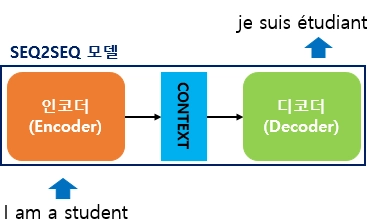  
- 한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용
- **Encoder**: 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비 => **컨텍스트 벡터(context vector)**
    - 컨텍스트 벡터 (Context Vector):  인코더 중 마지막 시점의 은닉 상태(hidden state)를 의미
    - t 시점의 임베딩된 단어의 입력,  t-1 시점의 은닉 상태 => t시점의 은닉 상태
- **Decoder**: 압축된 정보를 바탕으로 원하는 시퀀스를 생성
    - 인코더가 보내준 컨텍스트 벡터는 디코더의 첫번째 은닉 상태에 사용됨
    - t 시점에 나온 출력값이 그 다음 시점의 입력값으로 넘어감

## 5-2. Seq2Seq의 한계: 병목 현상 (Bottleneck)
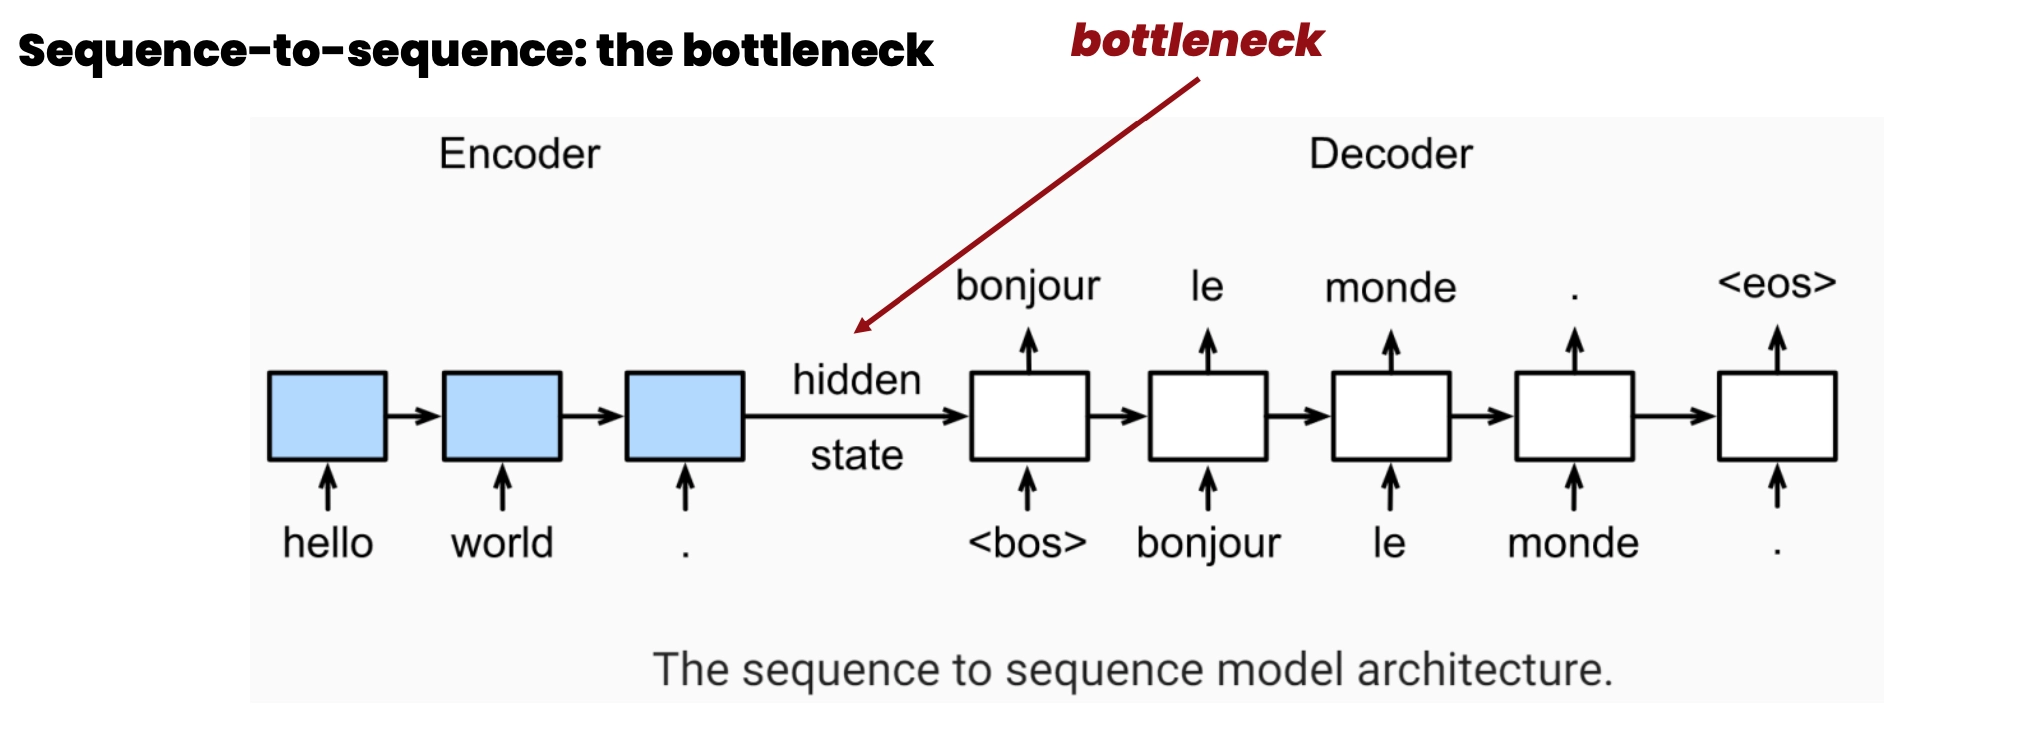  
- 고정된 Context Vector에 소스 문장의 정보 압축 → 병목 현상 발생
    - 고정된 길이에 입력 시퀸스의 모든 정보를 담지 못하고 손실될 수 있음
    